# Bank Loan Risk Analysis - Modeling 

This notebook re-tells the bank loan default modeling work with a **business-first narrative** and clearer commentary, using the engineered dataset prepared in earlier phases.

## Executive summary

- **Model type**  
  - Primary model: **regularized logistic regression** with a preprocessing pipeline (scaling numeric features and one-hot encoding categoricals).  
  - Evaluation focuses on **probability-based decisions and threshold tuning** rather than adding many complex models.

- **Key features (risk-increasing signals)**  
  - Previous loan default history (strongest driver of default odds).  
  - Larger requested loan amounts and certain high-risk loan purposes (e.g., venture, personal).  
  - Younger age buckets and mid-range credit score bands.

- **Key features (risk-reducing signals)**  
  - No prior default on record.  
  - Lower loan-to-income ratios and higher interest rate tiers (in this engineered portfolio).  
  - Renting vs owning in this dataset and poorer credit score band relative to the baseline band.

- **Headline performance (validation / test)**  
  - ROC AUC around **0.95–0.96**, meaning the model is highly effective at ranking risky vs safer loans.  
  - At a tuned default probability threshold of **≈0.62**, the model achieves **~80% recall** on defaults and **~98% precision** on defaults on the validation set, with accuracy in the low 80s. 
  - On the held-out test set at the same tuned threshold, performance remains stable with only a small drop in F1 and accuracy.

- **Business takeaways**  
  - For a high-default portfolio (~78% default rate), it is more impactful to **tune thresholds and decision bands** than to chase marginal gains from more complex models.
  - A three-band policy (Auto-Approve / Review / Auto-Reject) built on model probabilities creates a practical workflow for underwriters while controlling losses.
  - Default risk is dominated by prior behavior and leverage (loan size and loan-to-income), and these signals should be central to underwriting policy and monitoring.

The rest of this notebook walks through the modeling pipeline with concise commentary: data and target setup, model training, threshold selection, banded decision policy, and feature interpretation.


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization (optional but handy)
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import joblib
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, f1_score


# Notebook 3 configuration
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

ENGINEERED_INPUT_PATH = PROCESSED_DIR / "bank_loan_data_engineered.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ENGINEERED_INPUT_PATH:", ENGINEERED_INPUT_PATH, "exists?", ENGINEERED_INPUT_PATH.exists())

# Load engineered data for modeling
df = pd.read_csv(ENGINEERED_INPUT_PATH)
df.head()


PROJECT_ROOT: /Users/macbook/projects/data-science/bank-loan-risk
ENGINEERED_INPUT_PATH: /Users/macbook/projects/data-science/bank-loan-risk/data/processed/bank_loan_data_engineered.csv exists? True


,age,gender,education,income,employment_experience_length,home_ownership,loan_amount,loan_purpose,loan_interest_rate,loan_percent_to_income,...,age_outlier_z,income_capped,loan_amount_capped,loan_percent_to_income_capped,default_flag,age_bucket,credit_score_band,loan_percent_to_income_band,income_band,loan_amount_band
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,...,False,71948.0,28393.06,0.40,0,18_25,Poor,High / Risky,"Middle (60k–119,999)","Lower-mid (25,001–100k)"
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,...,False,12282.0,1000.00,0.08,1,18_25,Poor,Low / Strong,Low (<30k),Micro / very small (0–5k)
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,...,False,12438.0,5500.00,0.40,0,18_25,Fair,High / Risky,Low (<30k),"Small (5,001–25k)"
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,...,False,79753.0,28393.06,0.40,0,18_25,Good,High / Risky,"Middle (60k–119,999)","Lower-mid (25,001–100k)"
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,...,False,66135.0,28393.06,0.40,0,18_25,Fair,Excessive,"Middle (60k–119,999)","Lower-mid (25,001–100k)"


In [13]:
# Inspect schema
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44992 entries, 0 to 44991
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age                                 44992 non-null  float64
 1   gender                              44992 non-null  object 
 2   education                           44992 non-null  object 
 3   income                              44992 non-null  float64
 4   employment_experience_length        44992 non-null  int64  
 5   home_ownership                      44992 non-null  object 
 6   loan_amount                         44992 non-null  float64
 7   loan_purpose                        44992 non-null  object 
 8   loan_interest_rate                  44992 non-null  float64
 9   loan_percent_to_income              44992 non-null  float64
 10  credit_history_length               44992 non-null  float64
 11  credit_score                        44992

In [14]:
# Define target and feature columns
y = df["default_flag"]

num_cols = [
    "income_capped",
    "loan_amount_capped",
    "loan_interest_rate",
    "loan_percent_to_income_capped",
    "credit_history_length",
    "employment_experience_length",
]

cat_cols = [
    "loan_purpose",
    "gender",
    "education",
    "home_ownership",
    "previous_loan_default",
    "age_bucket",
    "credit_score_band",
]

X = df[num_cols + cat_cols]

# Check class balance
(df["default_flag"].value_counts(normalize=True) * 100).rename("proportion")

default_flag
1    77.773826
0    22.226174
Name: proportion, dtype: float64

## Dataset caveat – why this portfolio is unusual

In this engineered dataset, **approximately 78% of historical loans defaulted and only 22% were repaid**, which is the opposite of most real-world retail portfolios.

- Default rates in every segment will look extremely high compared with a prime book.
- Modeling emphasis is on **identifying and avoiding high-risk applicants**, not on forecasting typical bank-level default rates.
- We therefore pay close attention to **recall of defaulted loans** and use precision/F1 to balance how many good loans we sacrifice.
- The same techniques (probability modeling, threshold tuning, banded policies, odds-ratio interpretation) transfer directly to more typical class balances.

In [15]:
# Train / validation / test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=21, stratify=y_temp
)

print("Shapes:")
print("X_train, X_val, X_test:", X_train.shape, X_val.shape, X_test.shape)
print("y_train, y_val, y_test:", y_train.shape, y_val.shape, y_test.shape)

Shapes:
X_train, X_val, X_test: (26994, 13) (8999, 13) (8999, 13)
y_train, y_val, y_test: (26994,) (8999,) (8999,)


## Modeling approach and preprocessing pipeline

We use a **scikit-learn Pipeline** that:

- Standardizes numeric features such as capped income, capped loan amount, interest rate, loan-to-income ratio, credit history length, and employment tenure.
- One-hot encodes categorical features such as loan purpose, gender, education, home ownership, previous default flag, age bucket, and credit score band.
- Feeds the transformed features into a **class-weighted logistic regression** model, which outputs default probabilities for each application.


In [16]:
# Build preprocessing transformers
numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", numerical_transformer, num_cols),
        ("categories", categorical_transformer, cat_cols),
    ]
)

# Logistic regression model with class weights
logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
)

# Full pipeline
logregpipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logreg),
    ]
)

logregpipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('categories', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## Baseline validation performance (0.50 threshold)

We first train the model on the training set and score the validation set using the standard **0.50** probability threshold, treating loans with predicted default ≥ 0.50 as predicted defaults.

This gives us a benchmark for accuracy, recall, and precision before tuning the operating point for business needs.

In [17]:
# Fit model
logregpipeline.fit(X_train, y_train)

# Probabilities and class predictions on validation
y_val_proba = logregpipeline.predict_proba(X_val)[:, 1]
y_val_pred_05 = (y_val_proba >= 0.5).astype(int)

# Evaluation
val_roc_auc = roc_auc_score(y_val, y_val_proba)
print("Validation ROC AUC:", val_roc_auc)

print("Validation confusion matrix (threshold 0.5):")
print(confusion_matrix(y_val, y_val_pred_05))

print("Validation classification report (threshold 0.5):")
print(classification_report(y_val, y_val_pred_05, digits=3))

Validation ROC AUC: 0.9573031147306758
Validation confusion matrix (threshold 0.5):
[[1853  147]
 [1119 5880]]
Validation classification report (threshold 0.5):
              precision    recall  f1-score   support

           0      0.623     0.926     0.745      2000
           1      0.976     0.840     0.903      6999

    accuracy                          0.859      8999
   macro avg      0.800     0.883     0.824      8999
weighted avg      0.897     0.859     0.868      8999



/Users/macbook/projects/data-science/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Threshold tuning on validation

Rather than accept the 0.50 threshold by default, we sweep over many candidate thresholds and compute precision, recall, and F1 for the default class on the validation set.

The goal is to **target around 80% recall on defaults** (catching 4 out of 5 risky loans) while still keeping precision and F1 high.

In [18]:
# Sweep thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

thr_df = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),  # align length
    "precision": precision,
    "recall": recall,
})

# Helper: F1 at a given threshold
def f1_at_threshold(t):
    preds = (y_val_proba >= t).astype(int)
    return f1_score(y_val, preds)

thr_df["f1"] = thr_df["threshold"].apply(f1_at_threshold)
thr_df.sort_values("threshold", inplace=True)
thr_df.head(), thr_df.tail()

(   threshold  precision  recall        f1
 0   0.000503   0.777753     1.0  0.874984
 1   0.000709   0.777840     1.0  0.875039
 2   0.000759   0.777926     1.0  0.875094
 3   0.001165   0.778012     1.0  0.875148
 4   0.001205   0.778099     1.0  0.875203,
       threshold  precision    recall        f1
 8995   0.999998        1.0  0.000572  0.001142
 8996   0.999998        1.0  0.000429  0.000857
 8997   0.999998        1.0  0.000286  0.000571
 8998   0.999999        1.0  0.000143  0.000286
 8999   1.000000        1.0  0.000000  0.000000)

## Visualizing threshold trade-offs

To formalize threshold tuning, we first visualize how **precision**, **recall**, and **F1** change as we move the default probability threshold.

- Precision answers: *Of the loans we predict will default, how many actually default?*  
- Recall answers: *Of all the loans that actually default, how many did we correctly flag?*  
- F1 balances both, which is useful when we care about both catching defaults and not over-flagging good borrowers.


In [19]:
# Helper to pick best threshold subject to a minimum recall
def pick_threshold_for_recall(thr_df, target_recall):
    candidates = thr_df[thr_df["recall"] >= target_recall].copy()
    if candidates.empty:
        raise ValueError(f"No thresholds achieve recall {target_recall:.2f}")
    best = candidates.sort_values("precision", ascending=False).iloc[0]
    return {
        "target_recall": target_recall,
        "threshold": float(best["threshold"]),
        "precision": float(best["precision"]),
        "recall": float(best["recall"]),
        "f1": float(best["f1"]),
    }

best08 = pick_threshold_for_recall(thr_df, 0.80)
best08

{'target_recall': 0.8,
 'threshold': 0.6168805782727111,
 'precision': 0.9853950378321309,
 'recall': 0.800114302043149,
 'f1': 0.8831414603374862}

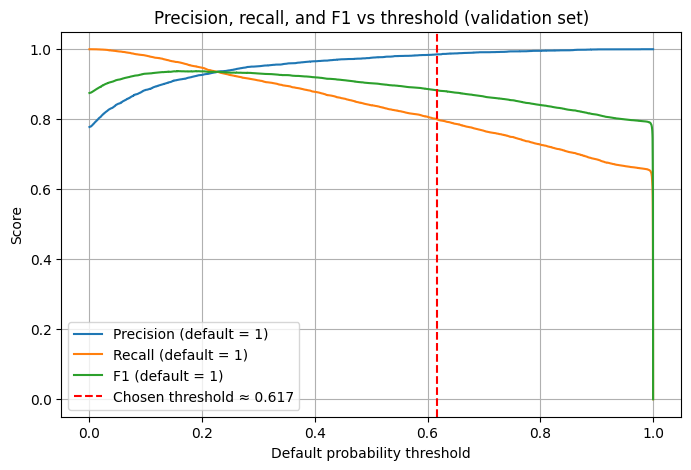

In [20]:
# Plot precision, recall, and F1 versus threshold

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(thr_df['threshold'], thr_df['precision'], label='Precision (default = 1)')
ax.plot(thr_df['threshold'], thr_df['recall'], label='Recall (default = 1)')
ax.plot(thr_df['threshold'], thr_df['f1'], label='F1 (default = 1)')

ax.axvline(best08['threshold'], color='red', linestyle='--', label=f"Chosen threshold ≈ {best08['threshold']:.3f}")

ax.set_xlabel('Default probability threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, recall, and F1 vs threshold (validation set)')
ax.legend()
ax.grid(True)
plt.show()

### Simple cost-based objective for choosing a threshold

Beyond pure metrics, we can express business preferences as a **cost-based objective**.

- Let each **false negative** (a default we mistakenly approve) cost \(C_{FN}\) units.  
- Let each **false positive** (a repaid loan we unnecessarily reject) cost \(C_{FP}\) units.

In a high-default portfolio, \(C_{FN} \gg C_{FP}\), because funding a doomed loan is much more expensive than missing a marginal good borrower.

We can estimate the **expected cost per application** for each threshold and pick the one that minimizes it.


Best threshold by cost objective: 0.1
Average cost per application: 0.1710190021113457


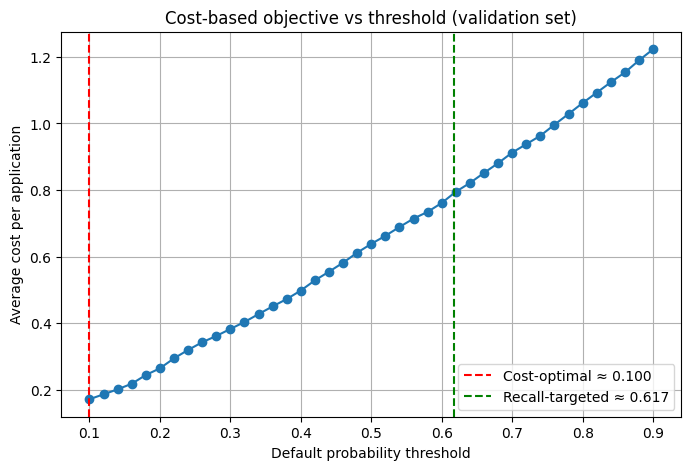

In [21]:
# Simple cost-based threshold selection on validation
# Define relative costs: missing a default is much worse than rejecting a good loan
C_FN = 5.0  # cost of approving a loan that will default (false negative)
C_FP = 1.0  # cost of rejecting a loan that would have repaid (false positive)

threshold_grid = np.linspace(0.1, 0.9, 41)
records = []

for thr in threshold_grid:
    preds = (y_val_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    total_cost = C_FN * fn + C_FP * fp
    avg_cost = total_cost / len(y_val)
    records.append({
        'threshold': thr,
        'fp': fp,
        'fn': fn,
        'avg_cost': avg_cost
    })

cost_df = pd.DataFrame(records)

best_cost_row = cost_df.sort_values('avg_cost').iloc[0]
print('Best threshold by cost objective:', best_cost_row['threshold'])
print('Average cost per application:', best_cost_row['avg_cost'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_df['threshold'], cost_df['avg_cost'], marker='o')
ax.axvline(best_cost_row['threshold'], color='red', linestyle='--', label=f"Cost-optimal ≈ {best_cost_row['threshold']:.3f}")
ax.axvline(best08['threshold'], color='green', linestyle='--', label=f"Recall-targeted ≈ {best08['threshold']:.3f}")
ax.set_xlabel('Default probability threshold')
ax.set_ylabel('Average cost per application')
ax.set_title('Cost-based objective vs threshold (validation set)')
ax.legend()
ax.grid(True)
plt.show()

This view lets a risk team tune the **cost ratio** \(C_{FN} / C_{FP}\) to represent their business appetite for loss versus forgone interest income, and see how the optimal threshold moves accordingly.


In [22]:
# Evaluate model at the chosen threshold on validation

t = best08["threshold"]
y_val_pred_t = (y_val_proba >= t).astype(int)

print("Custom threshold (target recall ~0.80):", t)
print("ROC AUC (probabilities):", roc_auc_score(y_val, y_val_proba))
print("Validation confusion matrix (threshold ~0.80 recall):")
print(confusion_matrix(y_val, y_val_pred_t))

print("Validation classification report (threshold ~0.80 recall):")
print(classification_report(y_val, y_val_pred_t, digits=3))

Custom threshold (target recall ~0.80): 0.6168805782727111
ROC AUC (probabilities): 0.9573031147306758
Validation confusion matrix (threshold ~0.80 recall):
[[1917   83]
 [1399 5600]]
Validation classification report (threshold ~0.80 recall):
              precision    recall  f1-score   support

           0      0.578     0.959     0.721      2000
           1      0.985     0.800     0.883      6999

    accuracy                          0.835      8999
   macro avg      0.782     0.879     0.802      8999
weighted avg      0.895     0.835     0.847      8999



## Logistic regression – validation metrics at key thresholds

The table below summarizes how the logistic regression model performs at the default 0.50 threshold versus the tuned ~0.62 threshold on the validation set.


### Why the ~0.62 threshold is a good operating point

At a threshold near **0.6169**, the model achieves roughly **80% recall for defaulted loans**, very high precision for defaults, and strong F1.

This operating point reflects a lender that is **more concerned with missing risky loans than with occasionally flagging a repayable borrower as risky**, which fits a high-default portfolio.

#### Threshold and baseline observations

- In this project, I treat the logistic regression model with the standard 0.50 threshold as the baseline. It provides a strong reference point for performance on this dataset, with high precision and good recall for defaulted loans and an overall ROC AUC of 0.957 on the validation set.

- I then tuned the decision threshold for the same logistic regression model. Setting the threshold to 0.617 (0.6169) was chosen by scanning thresholds and targeting roughly 80% recall for defaulted loans (class 1). This tuned operating point keeps ROC AUC unchanged but shifts the precision–recall balance, slightly lowering overall accuracy and F1 scores in exchange for a different mix of false positives and false negatives.

- I also tested the threshold that would yield approximately 75% recall for the defaulted class. In this dataset, that operating point did not improve the overall outcome: compared with the 0.50 and 0.617 thresholds.

- Overall, the comparison between the baseline logistic regression at the default 0.50 threshold and the alternative tuned threshold at 0.617 shows that threshold selection alone can materially change business‑relevant performance, even without changing the underlying model. This is more impactful for this problem than adding a more complex model on top of noisy data.

## Business framing – what the lender cares about

Because the historical portfolio is dominated by defaults, the lender primarily wants to **surface the safest 20–25% of applications** for approval and avoid as many doomed loans as possible.

We can articulate this as: *maximize precision on the repaid class while still approving at least a reasonable share of truly good borrowers*, subject to operational capacity for manual review.

## Final evaluation on held-out test set

After selecting the operating threshold on validation, we refit the model on **train + validation** and evaluate once on the held-out test set at the chosen threshold to simulate real-world deployment.

In [23]:
# Refit on train + validation
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

logregpipeline.fit(X_train_full, y_train_full)

# Predict on test
y_test_proba = logregpipeline.predict_proba(X_test)[:, 1]
y_test_pred_t = (y_test_proba >= t).astype(int)

print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))
print("Test confusion matrix (threshold ~0.80 recall):")
print(confusion_matrix(y_test, y_test_pred_t))

print("Test classification report (threshold ~0.80 recall):")
print(classification_report(y_test, y_test_pred_t, digits=3))

Test ROC AUC: 0.9502571081583084
Test confusion matrix (threshold ~0.80 recall):
[[1902   98]
 [1437 5562]]
Test classification report (threshold ~0.80 recall):
              precision    recall  f1-score   support

           0      0.570     0.951     0.712      2000
           1      0.983     0.795     0.879      6999

    accuracy                          0.829      8999
   macro avg      0.776     0.873     0.796      8999
weighted avg      0.891     0.829     0.842      8999



/Users/macbook/projects/data-science/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Translating probabilities into a three-band decision policy

Binary classification is useful for evaluation, but loan operations typically need **multiple actions**: automatically approve low-risk borrowers, automatically decline clearly high-risk ones, and send the ambiguous middle to a human underwriter.

We implement this with three bands based on predicted default probability: **Auto-Approve**, **Manual Review**, and **Auto-Reject**.

In [24]:
t_low = 0.20
t_high = 0.40

def decision_from_prob(p):
    if p < t_low:
        return "approve"
    elif p < t_high:
        return "review"
    else:
        return "reject"


test_df = pd.DataFrame({
    "y_true": y_test,
    "p_default": y_test_proba,
})

test_df["decision"] = test_df["p_default"].apply(decision_from_prob)

print("Test decision mix:")
print(test_df["decision"].value_counts(normalize=True))

print("Default rate by decision band (test):")
band_summary = test_df.groupby("decision")["y_true"].agg(
    n_loans="count",
    default_rate="mean",
)
print(band_summary)

Test decision mix:
decision
reject     0.709079
approve    0.197689
review     0.093233
Name: proportion, dtype: float64
Default rate by decision band (test):
          n_loans  default_rate
decision                       
approve      1779      0.208544
reject       6381      0.956903
review        839      0.622169


In [25]:
# Performance at binary threshold (0.6169)
print("Binary threshold (0.6169) — optimized for 80% default recall:")
print(classification_report(y_val, (y_val_proba >= 0.6169).astype(int)))

# Performance at three-band thresholds
print("\nThree-band policy performance on validation set:")

# Create bands
bands_val = pd.cut(
    y_val_proba, 
    bins=[0, 0.20, 0.40, 1.0],
    labels=['Approve', 'Review', 'Reject']
)

# Volume distribution
print("\nVolume distribution:")
# bands_val is a Categorical; convert to a Series before calling value_counts with normalize
print(pd.Series(bands_val).value_counts(normalize=True).sort_index())

# Actual default rates in each band
band_summary = pd.DataFrame({
    'Band': ['Approve', 'Review', 'Reject'],
    'Volume_%': [
        (bands_val == 'Approve').sum() / len(bands_val) * 100,
        (bands_val == 'Review').sum() / len(bands_val) * 100,
        (bands_val == 'Reject').sum() / len(bands_val) * 100
    ],
    'Actual_Default_Rate_%': [
        y_val[bands_val == 'Approve'].mean() * 100,
        y_val[bands_val == 'Review'].mean() * 100,
        y_val[bands_val == 'Reject'].mean() * 100
    ]
})
print("\nBand performance:")
print(band_summary)

Binary threshold (0.6169) — optimized for 80% default recall:
              precision    recall  f1-score   support

           0       0.58      0.96      0.72      2000
           1       0.99      0.80      0.88      6999

    accuracy                           0.84      8999
   macro avg       0.78      0.88      0.80      8999
weighted avg       0.89      0.84      0.85      8999


Three-band policy performance on validation set:

Volume distribution:
Approve    0.205023
Review     0.087454
Reject     0.707523
Name: proportion, dtype: float64

Band performance:
      Band   Volume_%  Actual_Default_Rate_%
0  Approve  20.502278              20.054201
1   Review   8.745416              61.245235
2   Reject  70.752306              96.544684


### Connecting the cost-based threshold to approve/review/reject bands

The **approve/review/reject bands** are simply ranges of default probability that implement an operating policy consistent with our chosen threshold and business costs.

One simple approach is:

- Set the **auto-reject lower bound** near the cost-optimal or recall-targeted threshold (e.g., around 0.62 in this portfolio).  
- Define an **auto-approve upper bound** where the predicted default probability is so low that almost all loans repay (e.g., < 0.20).  
- Treat the middle region as **manual review**, where underwriters can make case-by-case decisions and request more documentation.

If the risk team later updates the **cost ratio** \(C_{FN} / C_{FP}\) or adds volume/approval-rate constraints, we can recompute the preferred binary threshold and then **re-center the three bands** around that point (e.g., keeping the review band symmetric or skewed based on capacity). This makes the bands a transparent reflection of quantified business preferences rather than arbitrary cutoffs.


## Feature importance via odds ratios

Finally, we interpret the fitted logistic regression model by converting its coefficients into **odds ratios**, which show how each feature multiplies or reduces the odds of default, holding other factors constant.

We highlight the top drivers that increase risk and the features that most reduce risk, then translate these into plain-language business insights.

In [59]:
# Extract feature names from the preprocessor
feature_names = logregpipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = logregpipeline.named_steps["classifier"].coef_[0]
odds = np.exp(coefs)

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": odds,
}).sort_values("odds_ratio", ascending=False)

coef_table.head(20)

,feature,coef,odds_ratio
24,categories__previous_loan_default_Yes,5.345527,209.668295
21,categories__home_ownership_OWN,1.751004,5.760385
11,categories__loan_purpose_VENTURE,1.004844,2.731482
1,numbers__loan_amount_capped,0.778853,2.178971
30,categories__credit_score_band_Good,0.758467,2.135001
32,categories__credit_score_band_Very good,0.734188,2.083789
12,categories__gender_female,0.687878,1.989489
13,categories__gender_male,0.684834,1.983442
7,categories__loan_purpose_EDUCATION,0.567913,1.764580
25,categories__age_bucket_18_25,0.487620,1.628436


In [27]:
# Build natural-language interpretations

def make_interpretation(row):
    feature = row["feature"]
    or_val = row["odds_ratio"]
    if or_val > 1:
        # Risk-increasing
        if feature.startswith("numbers__"):
            return f"A higher value for this feature is associated with about {or_val:.2f}x higher odds that the loan will default, holding other factors constant."
        else:
            return f"Being in this category is associated with about {or_val:.2f}x higher odds that the loan will default compared with the baseline group."
    else:
        pct_lower = (1 - or_val) * 100
        if feature.startswith("numbers__"):
            return f"A higher value for this feature is associated with about {pct_lower:.1f}% lower odds that the loan will default, holding other factors constant."
        else:
            return f"Being in this category is associated with about {pct_lower:.1f}% lower odds that the loan will default compared with the baseline group."

coef_table["interpretation"] = coef_table.apply(make_interpretation, axis=1)

# Top 5 risk-increasing
top5_increase = (
    coef_table
    .sort_values("odds_ratio", ascending=False)
    .head(5)[["feature", "interpretation"]]
    .rename(columns={"feature": "feature name"})
)

# Top 5 risk-reducing
top5_decrease = (
    coef_table
    .sort_values("odds_ratio", ascending=True)
    .head(5)[["feature", "interpretation"]]
    .rename(columns={"feature": "feature name"})
)
from IPython.display import display

def style_interpretation_table(df):
    return (
        df.style
        .set_properties(
            subset=["interpretation"],
            **{
                "white-space": "normal",
                "text-align": "left",
                "max-width": "600px",
            },
        )
    )

print("Top 5 features increasing odds of default:")
display(style_interpretation_table(top5_increase))

print("Top 5 features reducing odds of default:")
display(style_interpretation_table(top5_decrease))


Top 5 features increasing odds of default:


,feature name,interpretation
24,categories__previous_loan_default_Yes,Being in this category is associated with about 209.67x higher odds that the loan will default compared with the baseline group.
21,categories__home_ownership_OWN,Being in this category is associated with about 5.76x higher odds that the loan will default compared with the baseline group.
11,categories__loan_purpose_VENTURE,Being in this category is associated with about 2.73x higher odds that the loan will default compared with the baseline group.
1,numbers__loan_amount_capped,"A higher value for this feature is associated with about 2.18x higher odds that the loan will default, holding other factors constant."
30,categories__credit_score_band_Good,Being in this category is associated with about 2.14x higher odds that the loan will default compared with the baseline group.


Top 5 features reducing odds of default:


,feature name,interpretation
23,categories__previous_loan_default_No,Being in this category is associated with about 98.1% lower odds that the loan will default compared with the baseline group.
3,numbers__loan_percent_to_income_capped,"A higher value for this feature is associated with about 76.9% lower odds that the loan will default, holding other factors constant."
2,numbers__loan_interest_rate,"A higher value for this feature is associated with about 62.9% lower odds that the loan will default, holding other factors constant."
31,categories__credit_score_band_Poor,Being in this category is associated with about 40.4% lower odds that the loan will default compared with the baseline group.
22,categories__home_ownership_RENT,Being in this category is associated with about 34.1% lower odds that the loan will default compared with the baseline group.
